# Detecção de mudança de conceito — KS e DDM no B-8802B (e B-4064A)

**Pergunta** (sugestão do especialista): usar **Kolmogorov–Smirnov** sobre os dados e **DDM** sobre o erro do modelo
para detectar concept drift, validando em mudanças conhecidas e medindo **quanto tempo / quantas observações o
detector leva para identificar o drift** a partir do momento em que ele ocorre.

**Casos com gabarito** (momento da mudança conhecido):

| caso | mudança | momento |
|---|---|---|
| A | drift grande 2022 → 2025 (reparo + regimes novos; modelo 2022 lendo o dado novo) | 1ª observação de 2025 |
| B | pós-falha de 2022 (falha + intervenção; 15 dias de dado depois) | 06/07/2022 10:00 |
| C | **controle**: modelo de produção lendo os próprios dados (2025 = treino; 2026 tem drift leve real) | — (disparo em 2025 seria falso) |
| D | B-4064A pós-reparo (mancal LNA ~+20 °C, evento documentado) — **sem modelo**, KS puro nos sensores | volta à operação, 14/01/2025 |

Métrica: **atraso = observações de operação (e dias corridos) entre a mudança e o 1º sinal**.

## Como se "treina" um detector de drift

Nenhum dos dois é treinado com gradiente — eles são **calibrados numa janela de referência** (a mesma janela de
treino do modelo, só operação). O "normal" deles é ancorado no que o modelo aprendeu, então o que detectam é
exatamente o que interessa: *o mundo mudou em relação ao treino do modelo*.

**KS deslizante (sobre sensores ou sobre o erro)** — não precisa do modelo quando aplicado aos sensores:
1. **Referência**: amostra dos valores de cada sensor na janela de treino (aqui, 5.000 pontos).
2. **Calibração do limiar**: o teste KS puro não serve com série autocorrelacionada — com n=288 qualquer dia dá
   p-valor minúsculo. Por isso o limiar do estatístico **D é auto-calibrado**: calcula-se o D de *cada dia da própria
   referência* contra a referência inteira, e o limiar = **máximo** desses D (absorve regime/campanha normais).
3. **Online**: a cada dia de operação (288 obs de 5 min), KS do dia contra a referência; **drift = 3 dias
   consecutivos** com D acima do limiar calibrado (e p<0,01).
4. **Recalibração**: sempre que o modelo é retreinado, a referência e os limiares são refeitos na janela nova.

**DDM (Drift Detection Method, Gama et al. 2004) — sobre o erro do modelo**:
1. Converte o erro num evento binário: `x = 1{erro > p99 do erro no treino}` (taxa esperada ~1 %).
2. Acompanha a taxa `p` e o desvio `s = √(p(1−p)/n)`; guarda o melhor ponto `p_min + s_min` (warm-up ≥ 30 obs).
3. **Warning** quando `p + s ≥ p_min + 2·s_min`; **drift** quando `≥ p_min + 3·s_min`; após drift (ou retreino), reseta.
4. **Ressalva medida abaixo**: aplicado às observações de 5 min ele é **inválido** neste dado (o i.i.d. do DDM é
   violado pela autocorrelação → dispara até no controle). A versão usada agrega **por dia**
   (`x_dia = 1{fração do dia acima do p99 > 2 %}`).

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src")); DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing

BLUE, ORANGE, RED, AMB, INK2 = "#2a78d6", "#eb6834", "#e34948", "#eda100", "#52514e"
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb"})

# ── dados e erros (bundles de deploy; CSVs de inferência já gerados pelo monitor) ──
B22 = next((DEP / "B-8802B/modelos").glob("model_*"))
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))
e22 = si.prever(B22, si.carregar_modelo(B22), si.preprocessar(B22, raw22))["reconstruction_error"]
ref_err22 = e22[:"2022-06-20"]; p99_22 = ref_err22.quantile(0.99)          # referência do modelo 2022
old = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)["reconstruction_error"]
prod = pd.read_csv(DEP / "B-8802B-2025/scripts/b8802b2025_inferencia.csv", index_col=0, parse_dates=True)["reconstruction_error"]
ref_err25 = prod[:"2025-12-31"]; p99_25 = ref_err25.quantile(0.99)          # referência do modelo de produção
cfg22, cfgN = EQUIPMENT_CONFIGS["B-8802B"], EQUIPMENT_CONFIGS["B-8802B-2025"]
pre22, _, _ = run_preprocessing(raw22, cfg22.pre_split_steps)               # 5 sensores, unidades brutas, 5 min
rawN = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-8802B-2025.feather").set_index("datetime")
preN22, _, _ = run_preprocessing(rawN, cfg22.pre_split_steps)               # dado novo no pipeline do modelo 2022
preN25, _, _ = run_preprocessing(rawN, cfgN.pre_split_steps)                # dado novo no pipeline da produção
print("setup ok:", len(e22), "obs 2022 |", len(old), "obs modelo-2022-em-2025-26 |", len(prod), "obs produção")

setup ok: 10792 obs 2022 | 145180 obs modelo-2022-em-2025-26 | 139264 obs produção


In [2]:
# ── detectores (mesma implementação do results/monitor_drift/bench_detectores.py, retornando trajetórias p/ plot) ──
def ks_scan(df, ref, win=288, n_ref=5000):
    """D do KS por janela de `win` obs de operação, por coluna + limiar D_crit auto-calibrado na referência."""
    refs = {c: ref[c].dropna().sample(min(len(ref), n_ref), random_state=0).values for c in df.columns}
    dcrit = {c: max(ks_2samp(refs[c], ref[c].values[i:i+win]).statistic for i in range(0, max(1, len(ref)-win), win)) for c in df.columns}
    rows, idx = [], []
    for i in range(0, len(df) - win, win):
        w = df.iloc[i:i+win]; idx.append(w.index[-1])
        rows.append({c: ks_2samp(refs[c], w[c].values).statistic for c in df.columns})
    return pd.DataFrame(rows, index=idx), dcrit

def ks_fire(D, dcrit, change_point, k_consec=3):
    """1º instante com k_consec janelas consecutivas (após a mudança) com D > D_crit em alguma coluna.
    Retorna (instante, sensores responsáveis) — responsáveis = acima do próprio limiar nos k dias do disparo."""
    above = D.gt(pd.Series(dcrit)); anyab = above.any(axis=1); run = 0
    for t, a in anyab.items():
        if t <= change_point: continue
        run = run + 1 if a else 0
        if run >= k_consec:
            jan = above.loc[:t].tail(k_consec)
            sens = [c for c in D.columns if jan[c].all()] or [c for c in D.columns if jan[c].any()]
            return t, sens
    return None, []

def ddm_daily(err, p99, change_point, min_inst=30, day_thr=0.02, min_obs_day=48):
    """DDM sobre o stream DIÁRIO x=1{fração do dia acima do p99 do treino > day_thr}. Retorna (warning, drift, trajetória)."""
    day = (err > p99).groupby(pd.Grouper(freq="D")).agg(["mean", "size"]); day = day[day["size"] >= min_obs_day]
    x = (day["mean"] > day_thr).astype(int)
    n = p = 0; p_min = s_min = np.inf; t_w = t_d = None; hist = []
    for t, xi in x.items():
        n += 1; p += (xi - p) / n
        if n < min_inst: continue
        s = np.sqrt(max(p * (1 - p), 1e-9) / n)
        if p + s < p_min + s_min: p_min, s_min = p, s
        hist.append((t, p + s, p_min + 2 * s_min, p_min + 3 * s_min))
        if t <= change_point: continue
        if t_w is None and p + s >= p_min + 2 * s_min: t_w = t
        if t_d is None and p + s >= p_min + 3 * s_min: t_d = t; break
    return t_w, t_d, pd.DataFrame(hist, columns=["t", "p_s", "warn", "drift"]).set_index("t")

def atraso(idx_operacao, cp, t):
    if t is None: return "não detecta"
    n = int(((idx_operacao > cp) & (idx_operacao <= t)).sum())
    return f"{t:%d/%m/%Y %H:%M} — {n} obs de operação, {(t - cp).total_seconds()/86400:.1f} dias"

def plot_caso(titulo, serie_diaria, ylabel, cp, marcas, idx_op, log=False, extra=None):
    """marcas = [(nome, instante_da_detecção_ou_None, cor)]; idx_op = índice das observações de operação
    (para contar quantas amostras se passaram entre a mudança e a detecção)."""
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(serie_diaria.index, serie_diaria.values, lw=1.2, color=BLUE)
    if log: ax.set_yscale("log")
    ax.axvline(cp, color="k", lw=1.6, label="mudança de conceito (gabarito)")
    for (nome, t, cor) in marcas:
        if t is None:
            ax.plot([], [], " ", label=f"{nome}: não disparou"); continue
        n = int(((idx_op > cp) & (idx_op <= t)).sum()); d = (t - cp).total_seconds() / 86400
        ax.axvline(t, color=cor, lw=1.8, ls="--", label=f"{nome}: detectou {d:.1f} dia(s) após a mudança  ·  {n} amostras")
        ax.axvspan(cp, t, color=cor, alpha=.05, lw=0)
    if extra: extra(ax)
    ax.set_ylabel(ylabel); ax.set_title(titulo, loc="left", fontsize=10.5)
    ax.grid(axis="y", lw=.5, color="#e6e5e1"); ax.set_axisbelow(True)
    ax.legend(loc="upper right", fontsize=9.5, framealpha=.95, edgecolor="#e6e5e1")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y" if (serie_diaria.index[-1] - serie_diaria.index[0]).days > 90 else "%d/%m"))
    plt.tight_layout(); plt.show()
print("detectores definidos")

detectores definidos


## Caso A — drift grande: modelo 2022 lendo 2025–26 (mudança em 01/01/2025)
A referência (treino do modelo 2022, mai–jun/22) e o dado novo estão em sequência; o detector só pode olhar o passado.

KS sensores : 03/01/2025 14:40 — 691 obs de operação, 2.6 dias — drift detectado via Vibração Bomba LA
KS erro     : 13/01/2025 01:25 — 3283 obs de operação, 12.1 dias
DDM diário  : 10/01/2025 00:00 — 2462 obs de operação, 9.0 dias [warning 06/01/2025]
(monitor semanal k-de-n, para comparação: vermelho na 4ª semana = 26 dias)


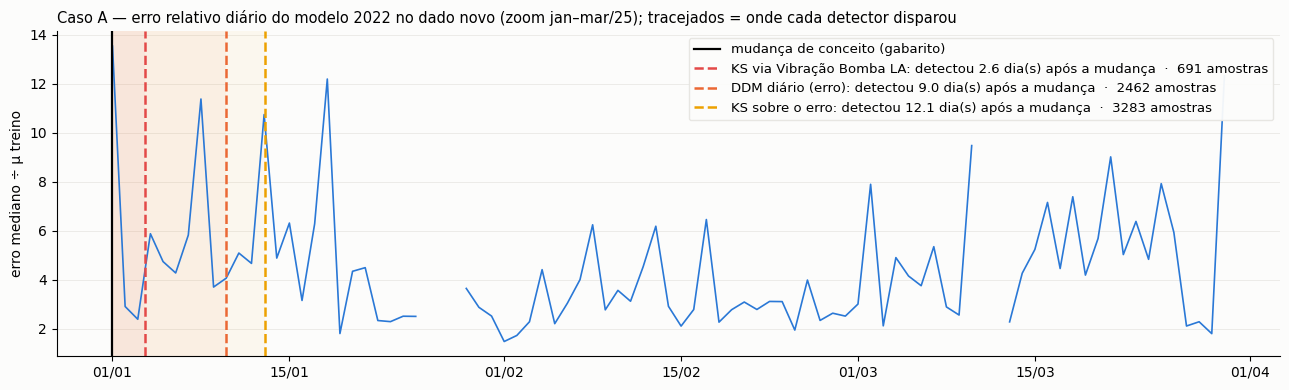

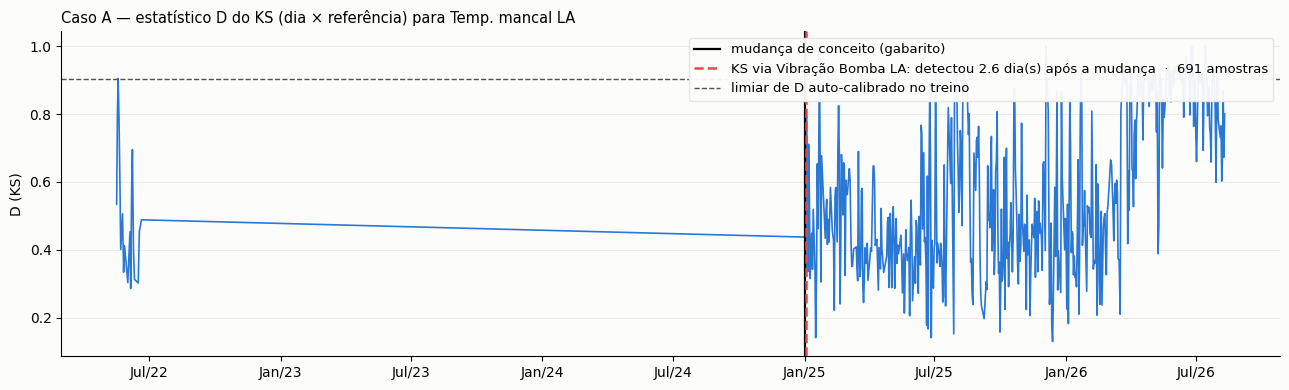

In [3]:
cpA = pd.Timestamp("2025-01-01")
featsA = pd.concat([pre22[:"2022-06-20"], preN22]); refA = pre22[:"2022-06-20"]
D_A, dcrit_A = ks_scan(featsA, refA)
t_ksA, sens_A = ks_fire(D_A, dcrit_A, cpA)
errA = pd.concat([ref_err22, old]).to_frame("erro")
D_Ae, dcrit_Ae = ks_scan(errA, errA.loc[:"2022-06-20"])
t_kseA, _ = ks_fire(D_Ae, dcrit_Ae, cpA)
twA, tdA, histA = ddm_daily(pd.concat([ref_err22, old]), p99_22, cpA)
print("KS sensores :", atraso(featsA.index, cpA, t_ksA), "— drift detectado via", ", ".join(sens_A))
print("KS erro     :", atraso(errA.index, cpA, t_kseA))
print("DDM diário  :", atraso(errA.index, cpA, tdA), f"[warning {twA:%d/%m/%Y}]")
print("(monitor semanal k-de-n, para comparação: vermelho na 4ª semana = 26 dias)")
dd = old["2025-01":"2025-03"].resample("D").median() / ref_err22.median()
plot_caso("Caso A — erro relativo diário do modelo 2022 no dado novo (zoom jan–mar/25); tracejados = onde cada detector disparou",
          dd, "erro mediano ÷ μ treino", cpA,
          [(f"KS via {', '.join(sens_A)}", t_ksA, RED), ("DDM diário (erro)", tdA, ORANGE), ("KS sobre o erro", t_kseA, AMB)], featsA.index)
# didático: o estatístico D diário da temperatura contra o limiar calibrado
Dt = D_A["Temperatura Bomba LA"]
plot_caso("Caso A — estatístico D do KS (dia × referência) para Temp. mancal LA",
          Dt[Dt.index >= "2022-05-16"], "D (KS)", cpA, [(f"KS via {', '.join(sens_A)}", t_ksA, RED)], featsA.index,
          extra=lambda ax: ax.axhline(dcrit_A["Temperatura Bomba LA"], color=INK2, ls="--", lw=1, label="limiar de D auto-calibrado no treino"))

## Caso B — pós-falha de 2022 (mudança em 06/07/2022 10:00; 15 dias de dado)

KS sensores : 10/07/2022 09:40 — 631 obs de operação, 4.0 dias — drift detectado via Vibração Bomba LA
DDM diário  : 08/07/2022 00:00 — 140 obs de operação, 1.6 dias [warning 07/07/2022]


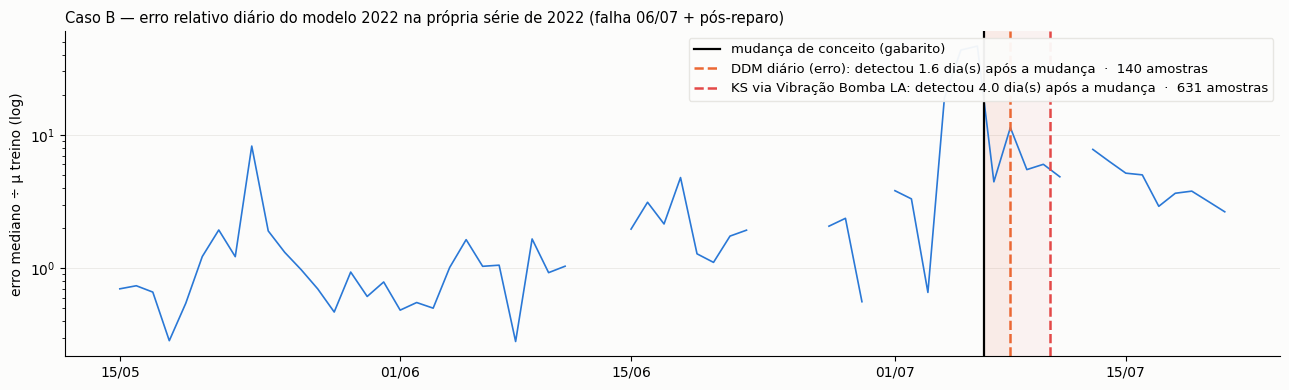

In [4]:
cpB = pd.Timestamp("2022-07-06 10:00")
D_B, dcrit_B = ks_scan(pre22, refA); t_ksB, sens_B = ks_fire(D_B, dcrit_B, cpB)
twB, tdB, histB = ddm_daily(e22, p99_22, cpB)
print("KS sensores :", atraso(pre22.index, cpB, t_ksB), "— drift detectado via", ", ".join(sens_B))
print("DDM diário  :", atraso(e22.index, cpB, tdB), f"[warning {twB:%d/%m/%Y}]")
dd = e22.resample("D").median() / ref_err22.median()
plot_caso("Caso B — erro relativo diário do modelo 2022 na própria série de 2022 (falha 06/07 + pós-reparo)",
          dd, "erro mediano ÷ μ treino (log)", cpB,
          [("DDM diário (erro)", tdB, ORANGE), (f"KS via {', '.join(sens_B)}", t_ksB, RED)], pre22.index, log=True)

## Caso C — controle: o modelo de produção nos próprios dados
2025 é o treino (qualquer disparo ali seria falso alarme). Em 2026 existe um drift **leve e real**
(erro relativo 1,1× → 2,2×; temperatura saindo da faixa aprendida) que o semáforo classifica como *amarelo* — um
detector que dispara "drift!" aqui está estatisticamente certo, mas seria **prematuro como gatilho de retreino**
(falso positivo do modelo continua 0,04 % e a sensibilidade está intacta).

KS sensores : não detecta
KS erro     : não detecta
DDM diário  : 02/01/2026 00:00 — 269 obs de operação, 1.0 dias [warning 2026-01-02 00:00:00]  ← dispara sobre o drift leve real: prematuro como AÇÃO


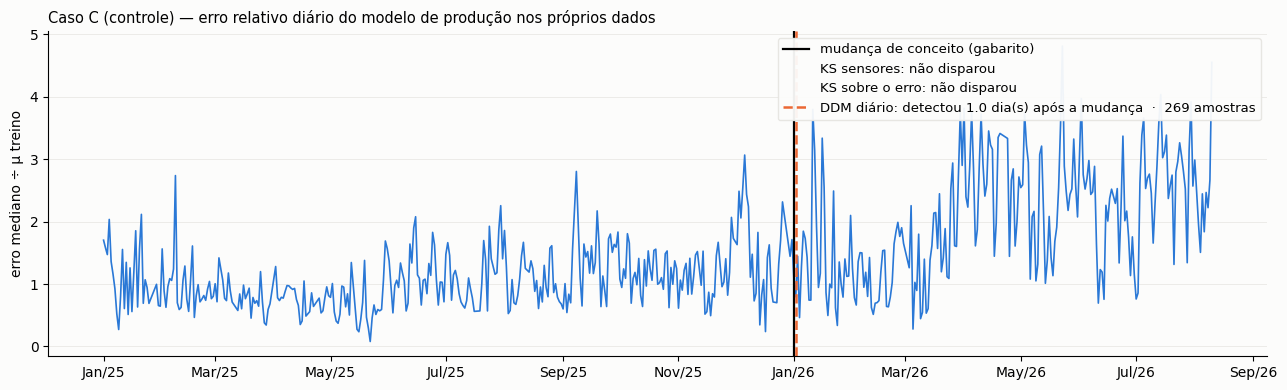

In [5]:
cpC = pd.Timestamp("2026-01-01")
D_C, dcrit_C = ks_scan(preN25, preN25[:"2025-12-31"]); t_ksC, _ = ks_fire(D_C, dcrit_C, cpC)
D_Ce, dcrit_Ce = ks_scan(prod.to_frame("erro"), ref_err25.to_frame("erro")); t_kseC, _ = ks_fire(D_Ce, dcrit_Ce, cpC)
twC, tdC, histC = ddm_daily(prod, p99_25, cpC)
print("KS sensores :", atraso(preN25.index, cpC, t_ksC))
print("KS erro     :", atraso(prod.index, cpC, t_kseC))
print("DDM diário  :", atraso(prod.index, cpC, tdC), f"[warning {twC}]  ← dispara sobre o drift leve real: prematuro como AÇÃO")
dd = prod.resample("D").median() / ref_err25.median()
plot_caso("Caso C (controle) — erro relativo diário do modelo de produção nos próprios dados",
          dd.dropna(), "erro mediano ÷ μ treino", cpC,
          [("KS sensores", None, RED), ("KS sobre o erro", None, AMB), ("DDM diário", tdC, ORANGE)], prod.index)

## Caso D — B-4064A pós-reparo (KS **sem modelo**; evento documentado: mancal LNA ≈ +20 °C)
Mostra que o KS nos sensores funciona antes de existir qualquer modelo para o equipamento (dado horário).

volta à operação: 2025-01-14 12:00:00
KS sensores : 17/01/2025 08:00 — 68 obs de operação, 2.8 dias — drift detectado via Temperatura Bomba LNA (o mancal do reparo!)


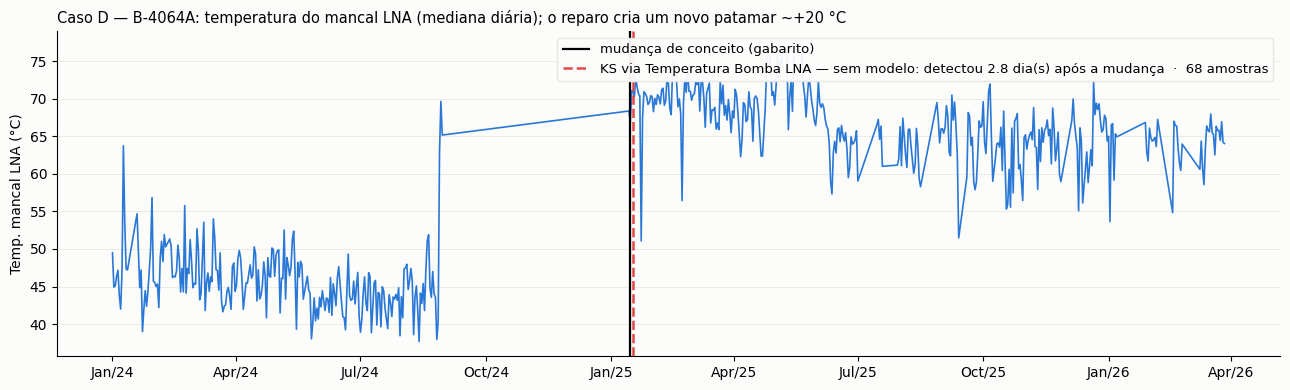

In [6]:
cfg4 = EQUIPMENT_CONFIGS["B-4064A-prod"]
raw4 = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-4064A_novos.feather")
if "Timestamp" in raw4.columns: raw4 = raw4.set_index("Timestamp"); raw4.index = pd.to_datetime(raw4.index)
pre4, _, _ = run_preprocessing(raw4, cfg4.pre_split_steps)
cpD = pre4.index[pre4.index > pd.Timestamp("2024-08-30 07:58") + pd.Timedelta(days=2)].min()   # volta à operação
D_D, dcrit_D = ks_scan(pre4, pre4[:"2024-08-20"], win=24)
t_ksD, sens_D = ks_fire(D_D, dcrit_D, cpD)
print("volta à operação:", cpD); print("KS sensores :", atraso(pre4.index, cpD, t_ksD), "— drift detectado via", ", ".join(sens_D), "(o mancal do reparo!)")
dd = pre4["Temperatura Bomba LNA"].resample("D").median()
plot_caso("Caso D — B-4064A: temperatura do mancal LNA (mediana diária); o reparo cria um novo patamar ~+20 °C",
          dd.dropna(), "Temp. mancal LNA (°C)", cpD, [(f"KS via {', '.join(sens_D)} — sem modelo", t_ksD, RED)], pre4.index)

## Caso E — teste de FALSO drift (fora da calibração)

O caso C não basta como controle: lá o KS foi calibrado no próprio 2025, então não disparar ali é quase por
construção. O teste honesto é **calibrar numa metade saudável e escanear a outra** (2025 inteiro não tem drift:
erro relativo 0,7–1,0× em todos os trimestres). Falso drift ocorre? Quanto a regra dos 3 dias consecutivos segura?

KS calib jan–jun/25 → scan jul–dez/25: 0 disparo(s) | dias isolados acima do limiar: 5/148
KS calib jul–dez/25 → scan jan–jun/25: 1 disparo(s) [('2025-05-19', ['Pressão Sucção', 'Vibração Bomba LA', 'Vibração Bomba LNA'])] | dias isolados: 12/140
DDM diário calib jan–jun/25 → scan jul–dez/25: FALSO disparo em 2025-12-29


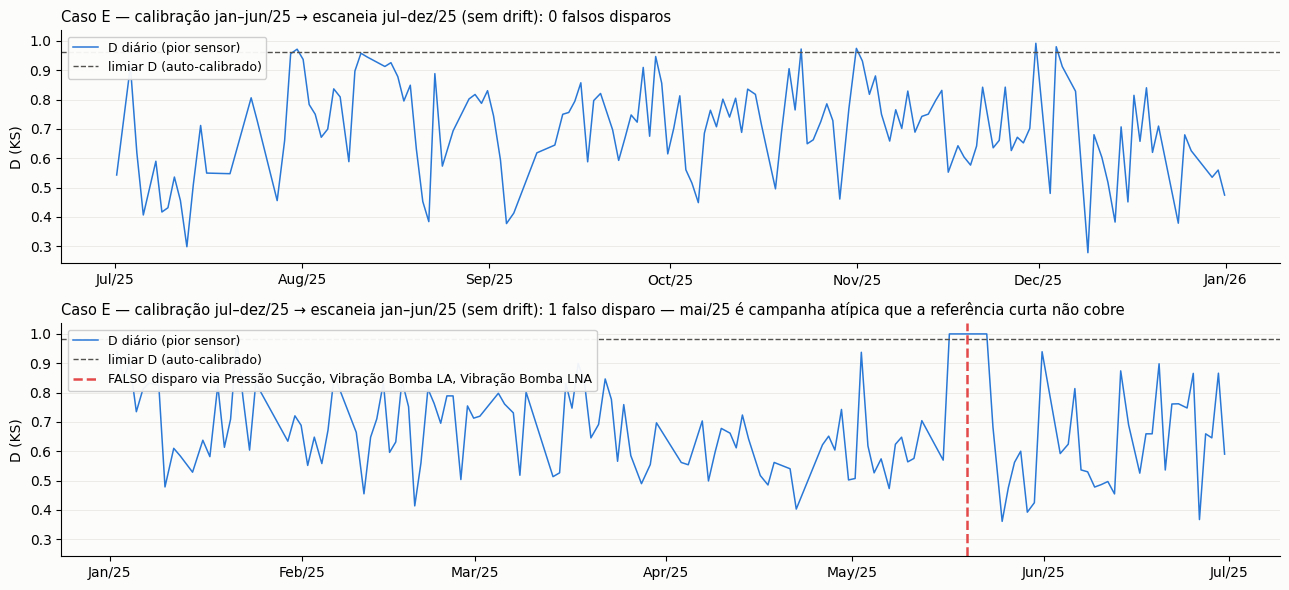

In [7]:
ref1, tst1 = preN25["2025-01-01":"2025-06-30"], preN25["2025-07-01":"2025-12-31"]
D1, dc1 = ks_scan(pd.concat([ref1, tst1]), ref1); D1t = D1[D1.index > "2025-07-01"]
ref2, tst2 = preN25["2025-07-01":"2025-12-31"], preN25["2025-01-01":"2025-06-30"]
D2, dc2 = ks_scan(pd.concat([tst2, ref2]).sort_index(), ref2); D2t = D2[D2.index < "2025-07-01"]
def fires_all(D, dcrit, k=3):
    ab = D.gt(pd.Series(dcrit)); anyab = ab.any(axis=1); out, run = [], 0
    for t, a in anyab.items():
        run = run + 1 if a else 0
        if run == k:
            jan = ab.loc[:t].tail(k); out.append((t, [c for c in D.columns if jan[c].all()] or [c for c in D.columns if jan[c].any()]))
    return out, anyab
f1, ab1 = fires_all(D1t, dc1); f2, ab2 = fires_all(D2t, dc2)
print(f"KS calib jan–jun/25 → scan jul–dez/25: {len(f1)} disparo(s) | dias isolados acima do limiar: {int(ab1.sum())}/{len(ab1)}")
print(f"KS calib jul–dez/25 → scan jan–jun/25: {len(f2)} disparo(s) {[(str(t)[:10], sens) for t, sens in f2]} | dias isolados: {int(ab2.sum())}/{len(ab2)}")
# DDM diário fora da calibração: warm-up jan–jun/25, escaneia jul–dez/25
_, tdE, _ = ddm_daily(prod["2025-01-01":"2025-12-31"], prod["2025-01-01":"2025-06-30"].quantile(0.99), pd.Timestamp("2025-07-01"))
print(f"DDM diário calib jan–jun/25 → scan jul–dez/25: {'FALSO disparo em ' + str(tdE)[:10] if tdE is not None else 'não dispara'}")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharey=True)
for ax, (Dt_, dc_, f_, titulo) in zip(axes, [
        (D1t, dc1, f1, "calibração jan–jun/25 → escaneia jul–dez/25 (sem drift): 0 falsos disparos"),
        (D2t, dc2, f2, "calibração jul–dez/25 → escaneia jan–jun/25 (sem drift): 1 falso disparo — mai/25 é campanha atípica que a referência curta não cobre")]):
    worst = Dt_.max(axis=1); ax.plot(worst.index, worst.values, lw=1.1, color=BLUE, label="D diário (pior sensor)")
    thr = min(dc_.values()); ax.axhline(max(dc_.values()), color=INK2, ls="--", lw=1, label="limiar D (auto-calibrado)")
    for t, sens in f_: ax.axvline(t, color=RED, lw=1.8, ls="--", label=f"FALSO disparo via {', '.join(sens)}")
    ax.set_ylabel("D (KS)"); ax.set_title("Caso E — " + titulo, loc="left", fontsize=10.5)
    ax.grid(axis="y", lw=.5, color="#e6e5e1"); ax.set_axisbelow(True); ax.legend(loc="upper left", fontsize=9, framealpha=.95)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.tight_layout(); plt.show()

## Síntese

| detector | A: 2022→2025 | B: pós-falha/22 | C: controle | D: B-4064A pós-reparo |
|---|---|---|---|---|
| **KS sensores** (1 dia, 3 consec., D_crit auto-calibrado) | **2,6 d** | **4,0 d** | não dispara ✓ | **2,8 d** (sem modelo) |
| KS sobre o erro | 12,1 d | — | não dispara ✓ | — |
| **DDM diário** sobre o erro | 9 d | **2 d** | dispara 02/01/26 (real, mas prematuro p/ ação) | — |
| DDM por observação (livro-texto) | 0,1 d | 0,0 d | **dispara no controle → inválido** (i.i.d. violado) | — |
| monitor semanal k-de-n (nosso) | 26 d | — | verde (amarelo por M5 desde abr/26) ✓ | — |

**Falso drift fora da calibração (caso E)**: KS com referência de 6 meses bem coberta → **0 falsos** em 6 meses
(5/148 dias isolados, absorvidos pela regra dos 3 consecutivos); com referência que não cobre todos os regimes →
**1 falso** (mai/25, campanha atípica); DDM diário → 1 falso (29/12/25).

1. **KS nos sensores** = melhor relação atraso × robustez, e funciona sem modelo → candidato a detector rápido (M6) do monitor.
   **Lição do caso E: a referência deve cobrir 12 meses** (todos os regimes), como a janela de treino.
2. **DDM** só funciona agregado por dia; é mais sensível — bom como *warning*, agressivo demais como gatilho de retreino
   (falso no caso E e prematuro no caso C).
3. A camada de **ação** continua sendo o semáforo semanal (custo de retreinar ≠ custo de investigar); os detectores
   rápidos encurtam o tempo até *saber* que algo mudou.
4. **Nunca ligar detector → retreino automático**: no caso B os detectores dispararam sobre a FALHA real — drift e
   degradação são indistinguíveis para o detector; retreinar ali ensinaria a falha ao modelo. O fluxo é
   detector → relatório/checklist → confirmação humana → pipeline de retreino.